In [14]:
from pathlib import Path
import csv

rnx_file = Path(r"C:\Users\erik\GNSS-Spoofing\data\BUDD00DNK_R_20260110000_01D_01S_MO.rnx")
out_file = Path("GPS_C1C_D1C.csv")

gps_obs_types = []

def split_obs_fields(obs_text, nobs):
    vals = []
    for i in range(nobs):
        chunk = obs_text[i * 16:(i + 1) * 16]
        raw = chunk[:14].strip() if chunk else ""
        try:
            vals.append(float(raw) if raw else None)
        except ValueError:
            vals.append(None)
    return vals

with open(rnx_file, "r", encoding="ascii", errors="ignore") as f:
    while True:
        line = f.readline()
        if not line:
            raise RuntimeError("Unexpected EOF before END OF HEADER")

        label = line[60:].rstrip()

        if label == "SYS / # / OBS TYPES":
            sys = line[0]
            nobs = int(line[3:6])
            obs_list = line[7:60].split()

            while len(obs_list) < nobs:
                pos = f.tell()
                nxt = f.readline()
                if not nxt:
                    raise RuntimeError("Unexpected EOF while reading SYS / # / OBS TYPES")
                if nxt[60:].rstrip() != "SYS / # / OBS TYPES":
                    f.seek(pos)
                    break
                obs_list.extend(nxt[7:60].split())

            if sys == "G":
                gps_obs_types = obs_list[:nobs]

        elif label == "END OF HEADER":
            break

if not gps_obs_types:
    raise RuntimeError("No GPS observation types found")

if "C1C" not in gps_obs_types or "D1C" not in gps_obs_types:
    raise RuntimeError(f"Need C1C and D1C, found: {gps_obs_types}")

gps_nobs = len(gps_obs_types)
c1c_idx = gps_obs_types.index("C1C")
d1c_idx = gps_obs_types.index("D1C")

print("GPS obs types:", gps_obs_types)
print("C1C index:", c1c_idx)
print("D1C index:", d1c_idx)

with open(rnx_file, "r", encoding="ascii", errors="ignore") as f, \
     open(out_file, "w", newline="", encoding="utf-8") as out:

    writer = csv.writer(out)
    writer.writerow(["time", "sv", "C1C_m", "D1C_hz"])

    # skip header
    while True:
        line = f.readline()
        if not line:
            raise RuntimeError("Unexpected EOF before data")
        if line[60:].rstrip() == "END OF HEADER":
            break

    while True:
        line = f.readline()
        if not line:
            break

        if not line.startswith(">"):
            continue

        year = int(line[2:6])
        month = int(line[7:9])
        day = int(line[10:12])
        hour = int(line[13:15])
        minute = int(line[16:18])
        second = float(line[19:29])
        nsat = int(line[32:35])

        epoch_str = f"{year:04d}-{month:02d}-{day:02d} {hour:02d}:{minute:02d}:{second:06.3f}"

        for _ in range(nsat):
            sat_line = f.readline()
            if not sat_line:
                break

            sv = sat_line[0:3]
            if not sv.startswith("G"):
                continue

            obs_text = sat_line[3:].rstrip("\n")
            needed_chars = gps_nobs * 16

            while len(obs_text) < needed_chars:
                pos = f.tell()
                cont = f.readline()
                if not cont:
                    break
                if cont.startswith(">") or (len(cont) >= 3 and cont[0].isalpha() and cont[1:3].isdigit()):
                    f.seek(pos)
                    break
                obs_text += cont.rstrip("\n")

            vals = split_obs_fields(obs_text, gps_nobs)
            c1c = vals[c1c_idx]
            d1c = vals[d1c_idx]

            writer.writerow([epoch_str, sv, c1c, d1c])

print(f"Wrote {out_file}")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\erik\\GNSS-Spoofing\\data\\BUDD00DNK_R_20260110000_01D_01S_MO.rnx'

In [ ]:
import pandas as pd

C_MPS = 299_792_458.0

df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])
df["delay_s"] = df["C1C_m"] / C_MPS
print(df.head())

        time   sv         C1C_m    D1C_hz   delay_s
0 2026-01-11  G01  2.147594e+07 -2593.314  0.071636
1 2026-01-11  G02  2.423982e+07 -3379.104  0.080855
2 2026-01-11  G03  1.992287e+07  -299.556  0.066456
3 2026-01-11  G04  2.156064e+07  2560.416  0.071919
4 2026-01-11  G06  2.365735e+07  3265.131  0.078912


In [ ]:
wanted = {"G03", "G06", "G09", "G16", "G21"}
df5 = df[df["sv"].isin(wanted)].copy()
print(df5.head())

                  time   sv         C1C_m    D1C_hz   delay_s
2  2026-01-11 00:00:00  G03  1.992287e+07  -299.556  0.066456
4  2026-01-11 00:00:00  G06  2.365735e+07  3265.131  0.078912
5  2026-01-11 00:00:00  G09  2.362591e+07  3751.470  0.078808
14 2026-01-11 00:00:01  G03  1.992292e+07  -299.885  0.066456
16 2026-01-11 00:00:01  G06  2.365673e+07  3264.915  0.078910


In [ ]:
sat_data = {
    sv: {
        "time": grp["time"].tolist(),
        "pseudorange_m": grp["C1C_m"].tolist(),
        "delay_s": grp["delay_s"].tolist(),
        "doppler_hz": grp["D1C_hz"].tolist(),
    }
    for sv, grp in df5.groupby("sv")
}

In [ ]:
import pandas as pd

# load extracted observations
df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])

# satellites you want
sv_order = ["G03", "G06", "G09", "G16", "G21"]

# time window
start_time = pd.Timestamp("2026-01-11 02:00:00")
end_time = start_time + pd.Timedelta(minutes=12.5)

# filter
window_df = df[
    (df["sv"].isin(sv_order)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

# keep sorted
window_df = window_df.sort_values(["time", "sv"]).reset_index(drop=True)

print(window_df.head(20))
print("rows:", len(window_df))
print("sats present:", window_df["sv"].unique())
print("time min/max:", window_df["time"].min(), window_df["time"].max())

                  time   sv         C1C_m    D1C_hz
0  2026-01-11 02:00:00  G03  2.255097e+07 -3219.178
1  2026-01-11 02:00:00  G06  2.128294e+07  -384.508
2  2026-01-11 02:00:00  G09  2.010980e+07   928.650
3  2026-01-11 02:00:00  G16  2.486342e+07  2978.751
4  2026-01-11 02:00:00  G21  2.474470e+07  3517.467
5  2026-01-11 02:00:01  G03  2.255158e+07 -3218.826
6  2026-01-11 02:00:01  G06  2.128301e+07  -384.570
7  2026-01-11 02:00:01  G09  2.010962e+07   928.705
8  2026-01-11 02:00:01  G16  2.486286e+07  2979.076
9  2026-01-11 02:00:01  G21  2.474403e+07  3517.945
10 2026-01-11 02:00:02  G03  2.255219e+07 -3219.120
11 2026-01-11 02:00:02  G06  2.128309e+07  -385.336
12 2026-01-11 02:00:02  G09  2.010945e+07   928.134
13 2026-01-11 02:00:02  G16  2.486229e+07  2978.723
14 2026-01-11 02:00:02  G21  2.474336e+07  3517.711
15 2026-01-11 02:00:03  G03  2.255280e+07 -3219.721
16 2026-01-11 02:00:03  G06  2.128316e+07  -386.284
17 2026-01-11 02:00:03  G09  2.010927e+07   927.283
18 2026-01-1

In [ ]:
sat_frames = {
    sv: grp.copy().reset_index(drop=True)
    for sv, grp in window_df.groupby("sv")
}

for sv in sv_order:
    if sv in sat_frames:
        print("\n", sv, len(sat_frames[sv]), "rows")
        print(sat_frames[sv].head())


 G03 751 rows
                 time   sv         C1C_m    D1C_hz
0 2026-01-11 02:00:00  G03  2.255097e+07 -3219.178
1 2026-01-11 02:00:01  G03  2.255158e+07 -3218.826
2 2026-01-11 02:00:02  G03  2.255219e+07 -3219.120
3 2026-01-11 02:00:03  G03  2.255280e+07 -3219.721
4 2026-01-11 02:00:04  G03  2.255342e+07 -3220.599

 G06 751 rows
                 time   sv         C1C_m   D1C_hz
0 2026-01-11 02:00:00  G06  2.128294e+07 -384.508
1 2026-01-11 02:00:01  G06  2.128301e+07 -384.570
2 2026-01-11 02:00:02  G06  2.128309e+07 -385.336
3 2026-01-11 02:00:03  G06  2.128316e+07 -386.284
4 2026-01-11 02:00:04  G06  2.128323e+07 -387.611

 G09 751 rows
                 time   sv         C1C_m   D1C_hz
0 2026-01-11 02:00:00  G09  2.010980e+07  928.650
1 2026-01-11 02:00:01  G09  2.010962e+07  928.705
2 2026-01-11 02:00:02  G09  2.010945e+07  928.134
3 2026-01-11 02:00:03  G09  2.010927e+07  927.283
4 2026-01-11 02:00:04  G09  2.010909e+07  926.082

 G16 751 rows
                 time   sv        

In [ ]:
import pandas as pd
import numpy as np

C_MPS = 299_792_458.0

# load full extracted GPS observations
df = pd.read_csv("GPS_C1C_D1C.csv")
df["time"] = pd.to_datetime(df["time"])

# exact satellites and time window
sv_order = ["G03", "G06", "G09", "G16", "G21"]
start_time = pd.Timestamp("2026-01-11 02:00:00")
end_time = start_time + pd.Timedelta(minutes=12.5)

# slice the window
window_df = df[
    (df["sv"].isin(sv_order)) &
    (df["time"] >= start_time) &
    (df["time"] <= end_time)
].copy()

window_df = window_df.sort_values(["time", "sv"]).reset_index(drop=True)
window_df["delay_s"] = window_df["C1C_m"] / C_MPS

print("rows:", len(window_df))
print("time min/max:", window_df["time"].min(), window_df["time"].max())
print("sats present:", window_df["sv"].unique())

# one dataframe per satellite
sat_frames = {
    sv: grp.copy().reset_index(drop=True)
    for sv, grp in window_df.groupby("sv")
}

# make sure all requested sats are present
for sv in sv_order:
    if sv not in sat_frames:
        print(f"Missing satellite: {sv}")

# build sat_data dict in the format you were already using
sat_data = {
    sv: {
        "time": sat_frames[sv]["time"].tolist(),
        "pseudorange_m": sat_frames[sv]["C1C_m"].tolist(),
        "delay_s": sat_frames[sv]["delay_s"].tolist(),
        "doppler_hz": sat_frames[sv]["D1C_hz"].tolist(),
    }
    for sv in sv_order
    if sv in sat_frames
}

# align into matrices with one common time index
pivot_pr = window_df.pivot(index="time", columns="sv", values="C1C_m").reindex(columns=sv_order)
pivot_delay = window_df.pivot(index="time", columns="sv", values="delay_s").reindex(columns=sv_order)
pivot_dopp = window_df.pivot(index="time", columns="sv", values="D1C_hz").reindex(columns=sv_order)

# interpolate missing values inside the window
pivot_pr = pivot_pr.interpolate(limit_direction="both")
pivot_delay = pivot_delay.interpolate(limit_direction="both")
pivot_dopp = pivot_dopp.interpolate(limit_direction="both")

# arrays for simulator: shape = (n_sats, n_times)
pseudorange_list = pivot_pr.to_numpy(dtype=float).T
delay_list = pivot_delay.to_numpy(dtype=float).T
doppler_list = pivot_dopp.to_numpy(dtype=float).T
time_list = pivot_delay.index.to_numpy()

print("pseudorange_list shape:", pseudorange_list.shape)
print("delay_list shape:", delay_list.shape)
print("doppler_list shape:", doppler_list.shape)
print("time_list shape:", time_list.shape)

# optional: show first few values for each sat
for i, sv in enumerate(sv_order):
    print(f"\n{sv}")
    print(" first times:", time_list[:3])
    print(" first pseudoranges:", pseudorange_list[i, :3])
    print(" first delays:", delay_list[i, :3])
    print(" first dopplers:", doppler_list[i, :3])

rows: 3755
time min/max: 2026-01-11 02:00:00 2026-01-11 02:12:30
sats present: <StringArray>
['G03', 'G06', 'G09', 'G16', 'G21']
Length: 5, dtype: str
pseudorange_list shape: (5, 751)
delay_list shape: (5, 751)
doppler_list shape: (5, 751)
time_list shape: (751,)

G03
 first times: ['2026-01-11T02:00:00.000000' '2026-01-11T02:00:01.000000'
 '2026-01-11T02:00:02.000000']
 first pseudoranges: [22550966.035 22551578.624 22552191.166]
 first delays: [0.07522193 0.07522397 0.07522601]
 first dopplers: [-3219.178 -3218.826 -3219.12 ]

G06
 first times: ['2026-01-11T02:00:00.000000' '2026-01-11T02:00:01.000000'
 '2026-01-11T02:00:02.000000']
 first pseudoranges: [21282939.357 21283012.485 21283085.85 ]
 first delays: [0.07099224 0.07099249 0.07099273]
 first dopplers: [-384.508 -384.57  -385.336]

G09
 first times: ['2026-01-11T02:00:00.000000' '2026-01-11T02:00:01.000000'
 '2026-01-11T02:00:02.000000']
 first pseudoranges: [20109800.981 20109624.281 20109447.688]
 first delays: [0.06707908 0

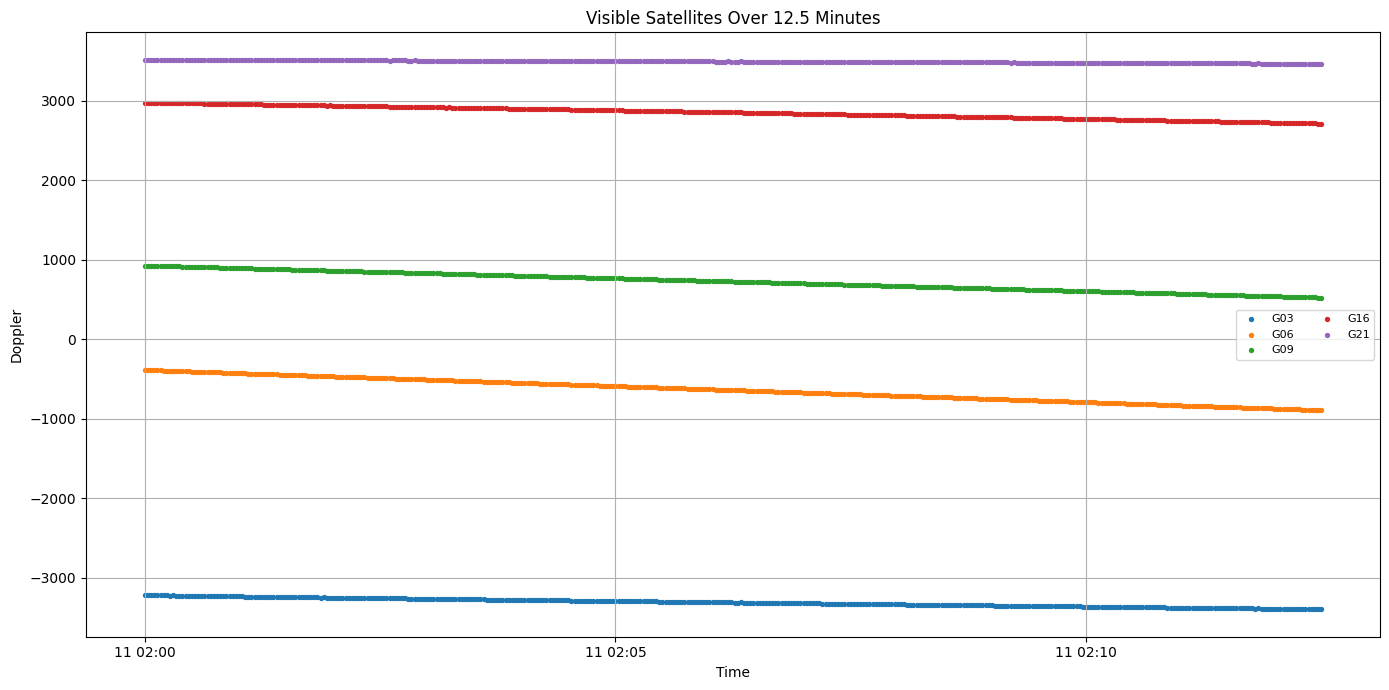

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14, 7))

for sat in visible:
    if sat in segments:
        t = pd.to_datetime(segments[sat]["time"])
        d = segments[sat]["doppler"]
        plt.scatter(t, d, label=sat, s=8)

plt.xlabel("Time")
plt.ylabel("Doppler")
plt.title("Visible Satellites Over 12.5 Minutes")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

def filter_continuous_satellites_15min(sat_data, start_time, max_gap_seconds=2):
    start = pd.Timestamp(start_time)
    end = start + pd.Timedelta(minutes=15)

    selected = {}

    for sv, data in sat_data.items():
        t = pd.to_datetime(data["time"]).sort_values()
        d = pd.Series(data["doppler"], index=t).sort_index()

        mask = (t >= start) & (t < end)
        t_win = t[mask]
        d_win = d.loc[t_win]

        if len(t_win) == 0:
            continue

        covers_window = (
            t_win[0] <= start and
            t_win[-1] >= end - pd.Timedelta(seconds=1)
        )

        gaps_ok = True
        if len(t_win) > 1:
            gaps = t_win.to_series().diff().dropna()
            gaps_ok = (gaps <= pd.Timedelta(seconds=max_gap_seconds)).all()

        if covers_window and gaps_ok:
            selected[sv] = {
                "time": t_win.tolist(),
                "doppler": d_win.tolist()
            }

    return selected

selected = filter_continuous_satellites_15min(
    sat_data,
    start_time="2026-01-11 02:00:00",
    max_gap_seconds=10000
)

print(sorted(selected.keys()))

[]


In [ ]:
import pandas as pd

t = pd.to_datetime(sat_data["G06"]["time"]).sort_values()

start = pd.Timestamp("2026-01-11 02:00:00")
end = start + pd.Timedelta(minutes=15)

mask = (t >= start) & (t < end)
t_win = t[mask]

print("total points:", len(t))
print("points in window:", len(t_win))

if len(t_win) > 0:
    print("first in window:", t_win[0])
    print("last in window:", t_win[-1])
    print("window start:", start)
    print("window end:", end)
    print("start diff (s):", (t_win[0] - start).total_seconds())
    print("end diff (s):", (end - t_win[-1]).total_seconds())

    if len(t_win) > 1:
        gaps = t_win.to_series().diff().dropna()
        print("max gap (s):", gaps.max().total_seconds())

total points: 8464
points in window: 450
first in window: 2026-01-11 02:00:00
last in window: 2026-01-11 02:14:58
window start: 2026-01-11 02:00:00
window end: 2026-01-11 02:15:00
start diff (s): 0.0
end diff (s): 2.0
max gap (s): 2.0


In [ ]:
import pandas as pd

time = pd.to_datetime(sat_data["G16"]["time"])
doppler = sat_data["G16"]["doppler"]

start = pd.Timestamp("2026-01-11 02:00:00")
end = start + pd.Timedelta(minutes=12, seconds=30)

mask = (time >= start) & (time <= end)

time_12_5min = time[mask].tolist()
doppler_12_5min = pd.Series(doppler)[mask].tolist()

print("number of points:", len(doppler_12_5min))
print("first time:", time_12_5min[0] if time_12_5min else None)
print("last time:", time_12_5min[-1] if time_12_5min else None)

number of points: 376
first time: 2026-01-11 02:00:00
last time: 2026-01-11 02:12:30
